# FairDerm: Fair Skin Lesion Classification

This notebook trains and evaluates skin lesion classifiers with a focus on fairness across skin tones.

**Methods compared:**
1. Baseline (CE + Uniform sampling)
2. Mixup (CE + Uniform + Mixup augmentation)
3. Reweighted (Weighted CE + Class-weighted sampling)
4. Focal Loss (Focal Loss gamma=2)
5. Proposed (CE + Skin-tone-adaptive sampling + Mixup)
6. **Proposed_GroupAug** (Proposed + Group-aware augmentation for minorities)

**Dataset:** Fitzpatrick17k (training/validation)

**Model:** EfficientNet-B2

## 1. Setup

In [1]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install timm --quiet

In [3]:
# Add fairderm package to path (if running from Colab)
import sys
sys.path.insert(0, '/content/drive/MyDrive/thesis/code')

# Import standard libraries
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import custom fairderm modules
from fairderm import (
    SkinLesionDataset,
    create_model,
    SkinToneAdaptiveSampler,
    get_class_weights,
    get_train_transforms,
    get_eval_transforms,
    run_experiment,
    save_experiment_results,
)
from fairderm.configs import (
    get_baseline_config,
    get_mixup_config,
    get_reweighted_config,
    get_focal_config,
    get_proposed_config,
    get_proposed_group_aug_config,  # NEW: Group-aware augmentation
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [4]:
import os

# Paths - update these for your setup
PROJECT_DIR = '/content/drive/MyDrive/thesis'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

CSV_PATH = os.path.join(DATA_DIR, 'fitzpatrick17k_processed.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Data directory: /content/drive/MyDrive/thesis/data
Results directory: /content/drive/MyDrive/thesis/results


## 3. Load and Prepare Data

In [5]:
# Load the processed CSV
df = pd.read_csv(CSV_PATH)

# Show dataset summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"\nTotal samples: {len(df)}")
print("\nLabel distribution:")
print(df['label_num'].value_counts())
print("\nSkin tone group distribution:")
print(df['tone_group'].value_counts())

# Cross-tabulation to see the breakdown
print("\nLabel x Skin Tone Group:")
print(pd.crosstab(df['label'], df['tone_group']))

DATASET SUMMARY

Total samples: 4491

Label distribution:
label_num
1    2260
0    2231
Name: count, dtype: int64

Skin tone group distribution:
tone_group
Light      2308
Medium     1599
Dark        409
Unknown     175
Name: count, dtype: int64

Label x Skin Tone Group:
tone_group  Dark  Light  Medium  Unknown
label                                   
benign       203   1113     842       73
malignant    206   1195     757      102


In [6]:
# Create stratified train/val split
# Stratify by BOTH label and skin tone to ensure balanced representation
df['stratify_key'] = df['label'].astype(str) + '_' + df['tone_group']

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['stratify_key']
)

train_df = train_df.drop('stratify_key', axis=1).reset_index(drop=True)
val_df = val_df.drop('stratify_key', axis=1).reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

print("\nTraining skin tone distribution:")
print(train_df['tone_group'].value_counts())

print("\nValidation skin tone distribution:")
print(val_df['tone_group'].value_counts())

Train set: 3592 samples
Val set: 899 samples

Training skin tone distribution:
tone_group
Light      1846
Medium     1279
Dark        327
Unknown     140
Name: count, dtype: int64

Validation skin tone distribution:
tone_group
Light      462
Medium     320
Dark        82
Unknown     35
Name: count, dtype: int64


In [ ]:
# Create datasets with transforms
# Resize to 260, then crop to 224
train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

train_dataset = SkinLesionDataset(train_df, transform=train_transform, return_group=True)
val_dataset = SkinLesionDataset(val_df, transform=eval_transform, return_group=True)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")

Train dataset: 3592 samples
Val dataset: 899 samples


## 4. Run Experiments

We run each method and compare results.

In [8]:
# Compute class weights for reweighted baseline
class_weights = get_class_weights(train_df, label_col='label_num')
print(f"Class weights: {class_weights}")

Class weights: tensor([1.0073, 0.9928])


In [9]:
# Store all results
all_results = {}

### 4.1 Baseline

In [11]:
config = get_baseline_config()
results = run_experiment(train_dataset, val_dataset, config, seed=42, device=device)
all_results['baseline_seed42'] = results

# Save model
save_experiment_results(results, 'baseline_seed42', RESULTS_DIR)


Experiment: Baseline (seed=42)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:05<00:00,  5.02it/s]

Train Loss: 0.5935 | Train Acc: 0.6840
Val Loss: 0.4988 | Val Acc: 0.7709

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:05<00:00,  5.00it/s]

Train Loss: 0.4411 | Train Acc: 0.7973
Val Loss: 0.4549 | Val Acc: 0.7998

Epoch 3/50


...

Train Loss: 0.0850 | Train Acc: 0.9702
Val Loss: 0.5677 | Val Acc: 0.8465

Epoch 15/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.91it/s]


Train Loss: 0.0948 | Train Acc: 0.9663
Val Loss: 0.6394 | Val Acc: 0.8532

Early stopping at epoch 15

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.31it/s]



Baseline Results:
  Accuracy: 0.8576
  Balanced Accuracy: 0.8576
  ROC-AUC: 0.9192

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8494 (n=462)
  Medium: 0.8609 (n=320)
  Dark: 0.8293 (n=82)
  -> Equal Opportunity Gap: 0.0317

Per-Group False Positive Rates:
  Light: 0.1570
  Medium: 0.1183
  Dark: 0.1463
  -> Equalized Odds Gap: 0.0386

Per-Group F1 Scores:
  Light: 0.8512
  Medium: 0.8638
  Dark: 0.8395
  -> Inter-group F1 Gap: 0.0243

Results saved to /content/drive/MyDrive/thesis/results/baseline_seed42


### 4.2 Mixup

In [12]:
config = get_mixup_config()
results = run_experiment(train_dataset, val_dataset, config, seed=42, device=device)
all_results['mixup_seed42'] = results

save_experiment_results(results, 'mixup_seed42', RESULTS_DIR)


Experiment: Mixup (seed=42)

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.92it/s]

Train Loss: 0.6264 | Train Acc: 0.6525
Val Loss: 0.5396 | Val Acc: 0.7397

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.78it/s]

Train Loss: 0.5402 | Train Acc: 0.7397
Val Loss: 0.4491 | Val Acc: 0.8131

Epoch 3/50


...

Train Loss: 0.2969 | Train Acc: 0.8860
Val Loss: 0.3854 | Val Acc: 0.8365

Epoch 23/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.91it/s]


Train Loss: 0.2837 | Train Acc: 0.8960
Val Loss: 0.3946 | Val Acc: 0.8365

Early stopping at epoch 23

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.30it/s]



Mixup Results:
  Accuracy: 0.8498
  Balanced Accuracy: 0.8500
  ROC-AUC: 0.9259

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8075 (n=462)
  Medium: 0.7947 (n=320)
  Dark: 0.8049 (n=82)
  -> Equal Opportunity Gap: 0.0128

Per-Group False Positive Rates:
  Light: 0.1300
  Medium: 0.0888
  Dark: 0.0732
  -> Equalized Odds Gap: 0.0569

Per-Group F1 Scores:
  Light: 0.8373
  Medium: 0.8392
  Dark: 0.8571
  -> Inter-group F1 Gap: 0.0198

Results saved to /content/drive/MyDrive/thesis/results/mixup_seed42


### 4.3 Reweighted

In [13]:
config = get_reweighted_config(class_weights, device=device)
results = run_experiment(train_dataset, val_dataset, config, seed=42, device=device)
all_results['reweighted_seed42'] = results

save_experiment_results(results, 'reweighted_seed42', RESULTS_DIR)


Experiment: Reweighted (seed=42)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  5.82it/s]

Train Loss: 0.5937 | Train Acc: 0.6849
Val Loss: 0.4982 | Val Acc: 0.7720

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:05<00:00,  4.91it/s]

Train Loss: 0.4406 | Train Acc: 0.7990
Val Loss: 0.4561 | Val Acc: 0.7942

Epoch 3/50


...

Train Loss: 0.0816 | Train Acc: 0.9691
Val Loss: 0.5617 | Val Acc: 0.8498

Epoch 15/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.65it/s]


Train Loss: 0.0927 | Train Acc: 0.9671
Val Loss: 0.6728 | Val Acc: 0.8476

Early stopping at epoch 15

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.22it/s]



Reweighted Results:
  Accuracy: 0.8565
  Balanced Accuracy: 0.8565
  ROC-AUC: 0.9191

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8452 (n=462)
  Medium: 0.8675 (n=320)
  Dark: 0.8293 (n=82)
  -> Equal Opportunity Gap: 0.0383

Per-Group False Positive Rates:
  Light: 0.1614
  Medium: 0.1183
  Dark: 0.1463
  -> Equalized Odds Gap: 0.0431

Per-Group F1 Scores:
  Light: 0.8470
  Medium: 0.8675
  Dark: 0.8395
  -> Inter-group F1 Gap: 0.0280

Results saved to /content/drive/MyDrive/thesis/results/reweighted_seed42


### 4.4 Focal Loss

In [14]:
config = get_focal_config()
results = run_experiment(train_dataset, val_dataset, config, seed=42, device=device)
all_results['focalloss_seed42'] = results

save_experiment_results(results, 'focalloss_seed42', RESULTS_DIR)


Experiment: FocalLoss (seed=42)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:06<00:00,  4.82it/s]

Train Loss: 0.1499 | Train Acc: 0.6871
Val Loss: 0.1285 | Val Acc: 0.7709

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:05<00:00,  5.17it/s]

Train Loss: 0.1182 | Train Acc: 0.7862
Val Loss: 0.1182 | Val Acc: 0.7898

Epoch 3/50


...

Train Loss: 0.0262 | Train Acc: 0.9635
Val Loss: 0.1795 | Val Acc: 0.8432

Epoch 14/50



Validating: 100%|██████████| 29/29 [00:05<00:00,  4.98it/s]


Train Loss: 0.0274 | Train Acc: 0.9635
Val Loss: 0.1692 | Val Acc: 0.8454

Early stopping at epoch 14

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:12<00:00,  2.38it/s]



FocalLoss Results:
  Accuracy: 0.8309
  Balanced Accuracy: 0.8310
  ROC-AUC: 0.9102

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.7992 (n=462)
  Medium: 0.8278 (n=320)
  Dark: 0.7561 (n=82)
  -> Equal Opportunity Gap: 0.0717

Per-Group False Positive Rates:
  Light: 0.1749
  Medium: 0.1006
  Dark: 0.1707
  -> Equalized Odds Gap: 0.0743

Per-Group F1 Scores:
  Light: 0.8145
  Medium: 0.8532
  Dark: 0.7848
  -> Inter-group F1 Gap: 0.0684

Results saved to /content/drive/MyDrive/thesis/results/focalloss_seed42


### 4.5 Proposed


Experiment: Proposed (seed=42)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Adaptive Sampler initialized
  Group sizes: {'Light': 1846, 'Medium': 1279, 'Dark': 327}
  Size weights: {'Light': 0.7182944072173485, 'Medium': 0.9286569033481047, 'Dark': 2.4125773474749472}
  Min prob floor: 0.1
  Alpha (loss vs size): 0.5

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: Yes
------------------------------------------------------------

Epoch 1/50


Training:   0%|          | 0/113 [00:00<?, ?it/s]

...

Train Loss: 0.2378 | Train Acc: 0.9152
Val Loss: 0.3650 | Val Acc: 0.8587
Sampling: Light=0.26, Medium=0.31, Dark=0.43

Epoch 31/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.51it/s]


Train Loss: 0.2780 | Train Acc: 0.8948
Val Loss: 0.3696 | Val Acc: 0.8532
Sampling: Light=0.28, Medium=0.28, Dark=0.44

Early stopping at epoch 31

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.31it/s]



Proposed Results:
  Accuracy: 0.8632
  Balanced Accuracy: 0.8632
  ROC-AUC: 0.9285

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8285 (n=462)
  Medium: 0.8874 (n=320)
  Dark: 0.8293 (n=82)
  -> Equal Opportunity Gap: 0.0590

Per-Group False Positive Rates:
  Light: 0.1480
  Medium: 0.0947
  Dark: 0.0976
  -> Equalized Odds Gap: 0.0590

Per-Group F1 Scores:
  Light: 0.8426
  Medium: 0.8904
  Dark: 0.8608
  -> Inter-group F1 Gap: 0.0478

Results saved to /content/drive/MyDrive/thesis/results/proposed_seed42


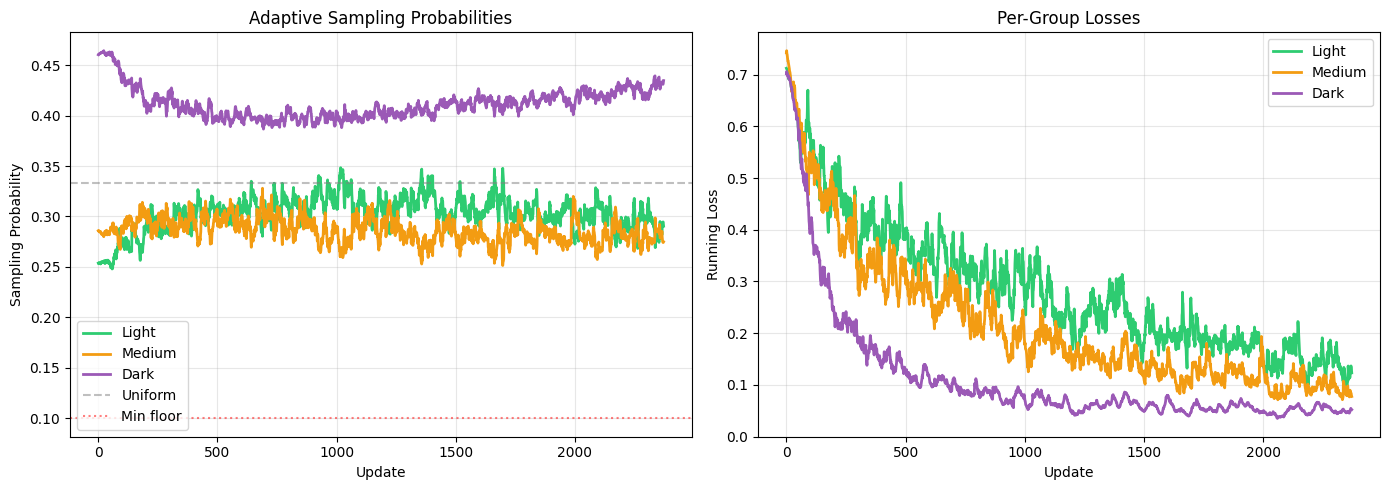

In [10]:
config = get_proposed_config()
results = run_experiment(train_dataset, val_dataset, config, seed=42, device=device)
all_results['proposed_seed42'] = results

save_experiment_results(results, 'proposed_seed42', RESULTS_DIR)

# Plot adaptive sampler history
if results['adaptive_sampler']:
    results['adaptive_sampler'].plot_history(
        save_path=os.path.join(RESULTS_DIR, 'proposed_seed42', 'sampler_history.png')
    )

### 4.6 Proposed with Group-Aware Augmentation

This extends the Proposed method with **group-aware augmentation**:
- **Light (majority)**: Standard augmentation (rotation ±20°, color jitter 0.2)
- **Medium/Dark (minority)**: Enhanced geometric augmentation (rotation ±180°, translation, scale) but **reduced color augmentation** to preserve diagnostic features

This is based on clinical validation using ABCDE criteria - color is diagnostic in dermatology, so we preserve it while increasing geometric diversity for minorities.

Using GROUP-AWARE augmentation:
  - Light (majority): Standard augmentation
  - Medium/Dark (minority): Enhanced geometric, reduced color augmentation

Experiment: Proposed_GroupAug (seed=42)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Adaptive Sampler initialized
  Group sizes: {'Light': 1846, 'Medium': 1279, 'Dark': 327}
  Size weights: {'Light': 0.7182944072173485, 'Medium': 0.9286569033481047, 'Dark': 2.4125773474749472}
  Min prob floor: 0.1
  Alpha (loss vs size): 0.5

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: Yes
------------------------------------------------------------

Epoch 1/50


Training:   0%|          | 0/113 [00:00<?, ?it/s]

...

Train Loss: 0.2724 | Train Acc: 0.8977
Val Loss: 0.3529 | Val Acc: 0.8498
Sampling: Light=0.27, Medium=0.31, Dark=0.42

Epoch 24/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.99it/s]


Train Loss: 0.2944 | Train Acc: 0.8856
Val Loss: 0.3928 | Val Acc: 0.8254
Sampling: Light=0.27, Medium=0.30, Dark=0.43

Early stopping at epoch 24

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:07<00:00,  3.75it/s]



Proposed_GroupAug Results:
  Accuracy: 0.8565
  Balanced Accuracy: 0.8566
  ROC-AUC: 0.9284

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8243 (n=462)
  Medium: 0.8675 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.1358

Per-Group False Positive Rates:
  Light: 0.1480
  Medium: 0.0828
  Dark: 0.0732
  -> Equalized Odds Gap: 0.1358

Per-Group F1 Scores:
  Light: 0.8401
  Medium: 0.8851
  Dark: 0.8108
  -> Inter-group F1 Gap: 0.0743

Results saved to /content/drive/MyDrive/thesis/results/proposed_groupaug_seed42


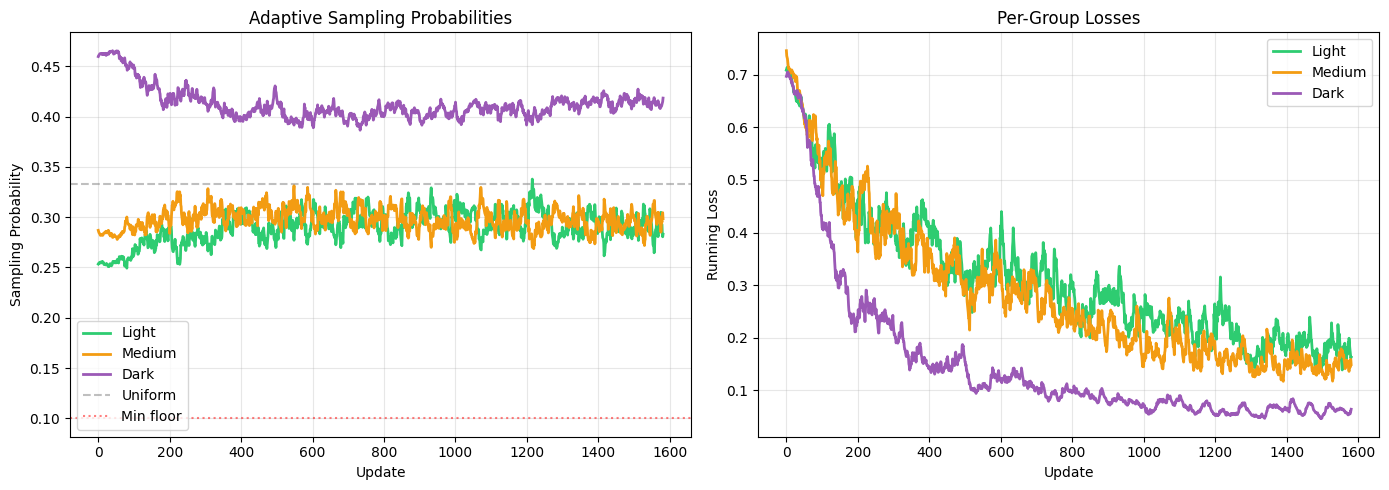

In [ ]:
# IMPORTANT: Pass train_df and val_df for group-aware augmentation to work
# The dataset will be recreated with per-group transforms
config = get_proposed_group_aug_config()
results = run_experiment(
    train_dataset, val_dataset, config, seed=42, device=device,
    train_df=train_df, val_df=val_df  # Required for group-aware augmentation
)
all_results['proposed_groupaug_seed42'] = results

save_experiment_results(results, 'proposed_groupaug_seed42', RESULTS_DIR)

# Plot adaptive sampler history
if results['adaptive_sampler']:
    results['adaptive_sampler'].plot_history(
        save_path=os.path.join(RESULTS_DIR, 'proposed_groupaug_seed42', 'sampler_history.png')
    )

## 5. Training Complete

All models have been trained and saved to the results directory. Each model folder contains:
- `model.pt` - Trained model weights
- `metrics.json` - Final validation metrics
- `training_history.csv` - Per-epoch training metrics
- `training_history.png` - Loss/accuracy curves

**For results analysis and visualization, see:** `fairderm_results_analysis.ipynb`

In [17]:
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"\nModels saved to: {RESULTS_DIR}")
print(f"\nTrained models:")
for name in all_results.keys():
    print(f"  - {name}")
print("\nRun 'fairderm_results_analysis.ipynb' for detailed analysis and visualizations.")

TRAINING COMPLETE

Models saved to: /content/drive/MyDrive/thesis/results

Trained models:
  - proposed_seed42
  - baseline_seed42
  - mixup_seed42
  - reweighted_seed42
  - focalloss_seed42

Run 'fairderm_results_analysis.ipynb' for detailed analysis and visualizations.
